# Analysis
## Prep

In [40]:
# Import necessary libraries
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json

# Load our results
with open(os.path.join("..", "dataset", "v", "results.json"), "r", encoding="utf-8") as f:
    data = json.load(f)

def time_to_seconds(time_str) -> int:
    """
    Converts a time string in 'MM:SS' format to total seconds.
    """
    try:
        # Detect format based on number of colons
        if time_str.count(':') == 1:
            fmt = "%M:%S"
        else:
            raise ValueError("Invalid time format")
        
        dt = datetime.strptime(time_str, fmt)
        # Convert to total seconds
        td = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second)
        return int(td.total_seconds())
    except ValueError:
        raise ValueError("Invalid time string. Use 'MM:SS' format")


## Claim #2

In [ ]:

rows_2nd_claim = []

for record in data:
    last = record["DetectionResults"][-1]
    rows_2nd_claim.append({
        "Id": record["Id"],
        "Is": record["Is"],
        "Human": 1 if record["HumanClassification"] == "Fraud" else 0,
        "Naive": 1 if last["NaiveClassification"]["Flag"] == "Fraud" else 0,
        "Enhanced": 1 if last["EnhancedClassification"]["Flag"] == "Fraud" else 0,
        "Duration-mean": time_to_seconds(record["RealDuration"]),
        "Duration-median": time_to_seconds(record["RealDuration"])
    })

df2 = pd.DataFrame(rows_2nd_claim)
groupby_2nd_claim = df2.groupby("Is").aggregate({
    "Id": "count",
    "Human": "sum",
    "Naive": "sum",
    "Enhanced": "sum",
    "Duration-mean": "mean",
    "Duration-median": "median",
})
groupby_2nd_claim.columns = ['Total', 'Human', 'Naive', 'Enhanced', 'Duration (mean)', 'Duration (median)']
result_2nd_claim = groupby_2nd_claim.round(decimals=2)
print (result_2nd_claim)


       Total  Human  Naive  Enhanced  Duration (mean)  Duration (median)
Is                                                                      
Fraud    101     24     65        52           115.31              106.0


## Claim #4 

In [ ]:
rows_4th_claim = []

for record in data:
    for subrecord in record["DetectionResults"]:
        rows_4th_claim.append({
            "Id": record["Id"],
            "Naive": subrecord["NaiveClassification"]["Duration"],
            "Enhanced": subrecord["EnhancedClassification"]["Duration"]
        })

df4 = pd.DataFrame(rows_4th_claim)
df4.describe()

,Naive,Enhanced
count,1186.000000,1186.000000
mean,5.020746,9.758773
std,2.900982,3.487511
min,1.262917,2.691135
25%,3.138606,7.469490
50%,4.138432,9.697108
75%,5.751044,11.942900
max,23.192220,27.864836


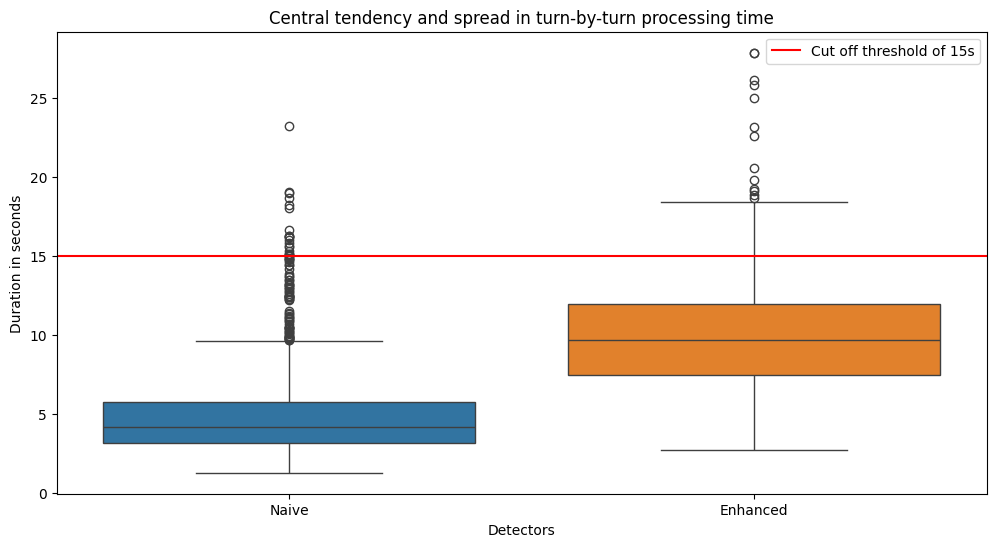

In [ ]:
# Boxplot to identify outliers
plt.figure(figsize=(12, 6))
bxp = sns.boxplot(data=df4.drop('Id', axis=1))
ax = plt.subplot(111)
ax.axhline(y = 15, color = 'r', label = 'Cut off threshold of 15s')
ax.set_xlabel("Detectors")
ax.set_ylabel("Duration in seconds")
plt.legend()
plt.title('Central tendency and spread in turn-by-turn processing time')
plt.show()

### What does all those outliers tell us?

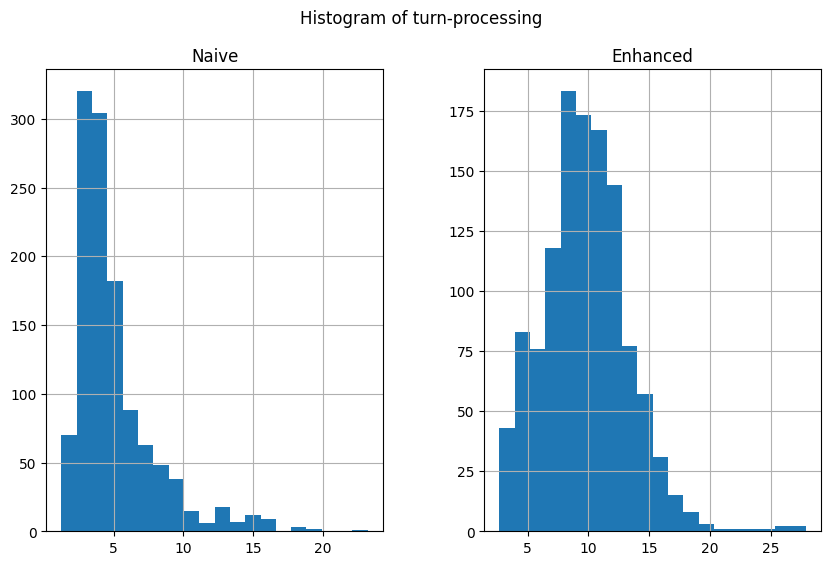

In [ ]:
# Histogram for each feature
hist = df4.drop('Id', axis=1).hist(figsize=(10, 6), bins=20)
plt.suptitle('Histogram of turn-processing')
plt.show()